# Lab Day 2 — DeepWeeds: backbone, công thức huấn luyện, suy luận

**Võ Minh Quân · 2A202602429**

Notebook chạy toàn bộ bài lab trên **Kaggle** (Save & Run All) hoặc **Google Colab** (Run all); tự nhận biết nền tảng.

| Bước | Ô | Nội dung | Tập dùng |
|---|---|---|---|
| 0 | 4 | Kiểm tra chia dữ liệu, EDA, loss ban đầu ≈ ln 9, overfit 1 batch | train/val |
| 1 | 5 | 6 backbone, cùng công thức nền, chọn backbone theo quy tắc định trước | **val** |
| 2 | 6–7 | T00 (3 seed) + 14 ablation + kết hợp, chọn công thức | **val** |
| 3 | 8 | ≥ 4 phương pháp suy luận, độ trễ p50/p95/p99, chọn phương pháp | **val** |
| 4 | 9 | Chung kết F01 × 3 seed, **test chạy một lần mỗi seed**, `eval.py score/grade` | **test** |
| 5 | 10 | `results.xlsx`, bảng, gói kết quả để nộp | — |

**Kaggle:** Settings → Accelerator **GPU T4 x2**, Internet **On** → *Save Version → Save & Run All (Commit)*.
Kết quả nằm trong tab *Output* của phiên bản đã lưu (`lab_day2_work/submission_outputs.zip`).
**Colab:** Runtime → Change runtime type → **T4 GPU** → *Run all*; kết quả lưu trên Google Drive.
**Bị ngắt?** Chạy lại: lần train đã xong được bỏ qua, lần đang dở tiếp tục từ epoch cuối.
Test của chung kết không bao giờ chạy lại.
Mọi lựa chọn (backbone, công thức, suy luận) dùng **quy tắc định trước trên val**, xem `code/experiments.py`
và `code/step3_inference.py`.

In [1]:
# ===================== CẤU HÌNH =====================
SMOKE = False   # True = chạy thử nhanh (4 ảnh/lớp, 1 epoch) chỉ để kiểm tra code; kết quả KHÔNG dùng để nộp
REPO_URL = "https://github.com/vminhquan/K4-Track4-Day2-VoMinhQuan-2A202602429.git"
BRANCH = "main"
import os
ON_KAGGLE = os.path.exists("/kaggle/working")
if ON_KAGGLE:
    DRIVE_DIR = "/kaggle/working/lab_day2_work"    # được lưu thành Output khi Save & Run All
    REPO = "/tmp/repo"                             # code + ảnh ở ổ tạm, không lẫn vào Output
    WORKERS = 4                                    # Kaggle có 4 CPU
else:
    DRIVE_DIR = "/content/drive/MyDrive/lab_day2_work"   # Colab: lưu trên Google Drive
    REPO = "/content/repo"
    WORKERS = 2                                    # Colab có 2 CPU
print("Nền tảng:", "Kaggle" if ON_KAGGLE else "Colab")

Nền tảng: Kaggle


In [2]:
# Ô 1 — (Colab: Drive), code, thư viện, GPU
import os, sys, subprocess
if not ON_KAGGLE:
    from google.colab import drive
    drive.mount("/content/drive")

if not os.path.exists(REPO):
    subprocess.run(["git", "clone", "-q", "-b", BRANCH, REPO_URL, REPO], check=True)
else:
    subprocess.run(["git", "-C", REPO, "pull", "-q"], check=True)
print(subprocess.run(["git", "-C", REPO, "log", "--oneline", "-1"], capture_output=True, text=True).stdout)

CODE = f"{REPO}/submissions/2A202602429_vo_minh_quan/code"
WORK = ("/tmp/smoke" if ON_KAGGLE else "/content/smoke") if SMOKE else DRIVE_DIR
os.makedirs(WORK, exist_ok=True)
os.chdir(WORK)

!pip -q install timm fvcore openpyxl tabulate

import torch, timm, torchvision, platform
assert torch.cuda.is_available(), ("Chưa bật GPU: Kaggle → Settings → Accelerator → GPU T4 x2; "
                                   "Colab → Runtime → Change runtime type → T4 GPU")
print("GPU:", torch.cuda.get_device_name(0))
print("python", platform.python_version(), "| torch", torch.__version__, "| torchvision", torchvision.__version__,
      "| timm", timm.__version__)
print("Thư mục làm việc:", WORK, "| SMOKE =", SMOKE)

aaa5cb6 Notebook runs on Kaggle and Colab

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 1.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 1.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.6/129.6 kB 4.5 MB/s eta 0:00:00
GPU: Tesla T4
python 3.13.15 | torch 2.11.0+cu128 | torchvision 0.26.0+cu128 | timm 1.0.29
Thư mục làm việc: /kaggle/working/lab_day2_work | SMOKE = False


In [3]:
# Hàm chạy script: in log trực tiếp và DỪNG notebook nếu script lỗi (để Run all không đi tiếp với kết quả thiếu)
SKIP = ("HF_TOKEN", "check_worker_number_rationality", "suggested max number of worker")

def sh(*args):
    env = dict(os.environ, PYTHONWARNINGS="ignore", PYTHONUNBUFFERED="1")
    if SMOKE:
        env["LAB_SMOKE"] = "4"
    cmd = [sys.executable, *map(str, args)]
    print("$", " ".join(cmd[1:]), flush=True)
    p = subprocess.Popen(cmd, cwd=WORK, env=env, stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True)
    for line in p.stdout:
        if not any(s in line for s in SKIP):
            print(line, end="", flush=True)
    if p.wait():
        raise RuntimeError(f"Lệnh lỗi (mã {p.returncode}): {' '.join(map(str, args))} — xem log phía trên")

In [4]:
# Ô 2 — Dữ liệu: images.zip (Zenodo, kiểm tra MD5, lưu đệm trên Drive) + nhãn fold 0 (GitHub tác giả)
import hashlib, urllib.request, zipfile

DATA = f"{REPO}/data"
IMAGES = f"{DATA}/images"
os.makedirs(f"{DATA}/labels", exist_ok=True)
ZIP = "/tmp/images.zip" if ON_KAGGLE else f"{DRIVE_DIR}/images.zip"   # Colab: lưu đệm trên Drive
os.makedirs(DRIVE_DIR, exist_ok=True)

if not (os.path.isdir(IMAGES) and len(os.listdir(IMAGES)) == 17509):
    if not os.path.exists(ZIP):
        print("Tải images.zip (~490 MB)...")
        urllib.request.urlretrieve("https://zenodo.org/records/7939060/files/images.zip?download=1", ZIP)
    h = hashlib.md5()
    with open(ZIP, "rb") as f:
        for chunk in iter(lambda: f.read(1 << 20), b""):
            h.update(chunk)
    assert h.hexdigest() == "b7b30f96d466fba86016aa5a26606e0f", f"MD5 sai: {h.hexdigest()} — xoá {ZIP} rồi chạy lại"
    print("MD5 đúng. Giải nén vào ổ cục bộ...")
    with zipfile.ZipFile(ZIP) as z:
        z.extractall(IMAGES)
print("Số ảnh:", len(os.listdir(IMAGES)))

BASE = "https://raw.githubusercontent.com/AlexOlsen/DeepWeeds/master/labels"
for n in ["labels", "train_subset0", "val_subset0", "test_subset0"]:
    if not os.path.exists(f"{DATA}/labels/{n}.csv"):
        urllib.request.urlretrieve(f"{BASE}/{n}.csv", f"{DATA}/labels/{n}.csv")
print(sorted(os.listdir(f"{DATA}/labels")))

Tải images.zip (~490 MB)...
MD5 đúng. Giải nén vào ổ cục bộ...
Số ảnh: 17509
['labels.csv', 'test_subset0.csv', 'train_subset0.csv', 'val_subset0.csv']


In [5]:
# Ô 3 — Test tự viết cho các phần dễ sai (focal γ=0 ≡ CE, CutMix λ theo diện tích, gộp BN, EMA, LR warmup+cosine...)
r = subprocess.run([sys.executable, "-m", "unittest", "test_code"], cwd=CODE, capture_output=True, text=True,
                   env=dict(os.environ, PYTHONWARNINGS="ignore"))
print(r.stderr[-600:])
assert r.returncode == 0, "Test thất bại"

..................
----------------------------------------------------------------------
Ran 18 tests in 4.545s

OK



## Bước 0 — Kiểm tra dữ liệu và pipeline (README 2.1, GUIDE 1.2–1.3)

$ /tmp/repo/submissions/2A202602429_vo_minh_quan/code/step0_checks.py
Số ảnh: {'train': 10501, 'val': 3501, 'test': 3507} | tỉ lệ: {'train': 0.5997, 'val': 0.2, 'test': 0.2003}
Giao: {'train∩val': 0, 'train∩test': 0, 'val∩test': 0} | hợp: 17509 | thiếu file: 0
                train   val  test
Chinee Apple      675   225   226
Lantana           637   213   213
Parkinsonia       618   206   207
Parthenium        613   204   205
Prickly Acacia    637   212   213
Rubber Vine       605   202   202
Siam Weed         644   215   215
Snake Weed        609   203   204
Negatives        5463  1821  1822
Khớp Table 1 bài báo: True | tỉ lệ lớn nhất/nhỏ nhất = 9.02
Thống kê ảnh: {'sizes': [[256, 256]], 'modes': ['RGB'], 'mean_rgb': [0.3411000072956085, 0.3517000079154968, 0.3425000011920929], 'std_rgb': [0.227400004863739, 0.22669999301433563, 0.22439999878406525]}
Loss ban đầu 2.1791 (ln 9 = 2.1972)
Overfit 16 ảnh: loss 2.232 -> 0.0176, acc (eval mode) 1.000


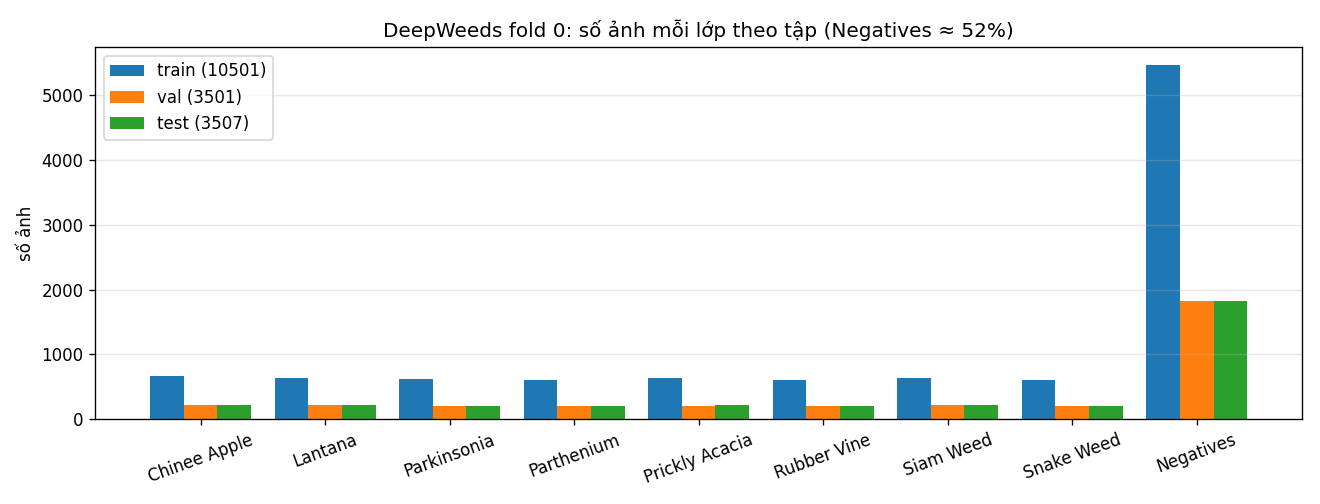

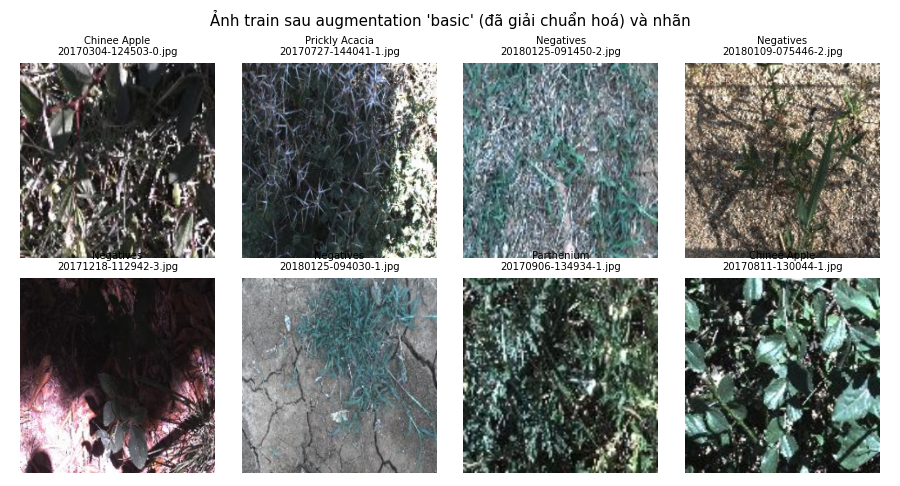

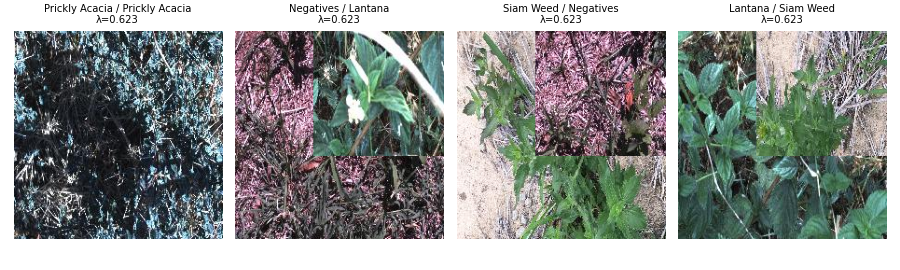

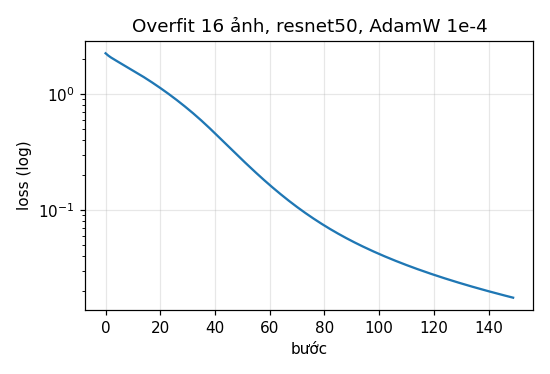

In [6]:
sh(f"{CODE}/step0_checks.py")
from IPython.display import Image, display
for f in ["eda_class_distribution.png", "aug_basic.png", "aug_cutmix.png", "overfit_one_batch.png"]:
    display(Image(f"figures/{f}", width=700))

## Bước 1 — So sánh 6 backbone (cùng công thức nền, seed 0, 10 epoch) và chọn backbone theo val

In [7]:
sh(f"{CODE}/experiments.py", "--group", "B", "--preload")
sh(f"{CODE}/experiments.py", "--select-backbone")
import pandas as pd, json
pd.set_option("display.width", 250); pd.set_option("display.max_columns", 30)
display(pd.read_csv("results/backbones.csv")[["exp_id", "backbone", "weight_tag", "params_M", "gmacs", "val_macro_f1",
        "val_top1", "train_time_per_epoch_s", "lat_b1_p50_ms", "lat_b1_p95_ms"]])
print(json.load(open("results/selection.json"))["backbone_reason"])

$ /tmp/repo/submissions/2A202602429_vo_minh_quan/code/experiments.py --group B --preload
[B01 seed0] resnet50.a1_in1k | 23.53M params | 4.109 GMAC | device cuda | amp True | 164 bước/epoch
  ep  1 | train 1.6499 | val loss 1.2611 | val F1 0.2260 | top1 0.5678 | 52s *
  ep  2 | train 0.9662 | val loss 0.7813 | val F1 0.5951 | top1 0.7247 | 39s *
  ep  3 | train 0.6996 | val loss 0.6134 | val F1 0.7017 | top1 0.7881 | 41s *
  ep  4 | train 0.5710 | val loss 0.5533 | val F1 0.7307 | top1 0.8063 | 42s *
  ep  5 | train 0.5036 | val loss 0.5124 | val F1 0.7559 | top1 0.8221 | 43s *
  ep  6 | train 0.4807 | val loss 0.4854 | val F1 0.7714 | top1 0.8343 | 43s *
  ep  7 | train 0.4372 | val loss 0.4780 | val F1 0.7795 | top1 0.8412 | 43s *
  ep  8 | train 0.4221 | val loss 0.4565 | val F1 0.7864 | top1 0.8455 | 43s *
  ep  9 | train 0.4173 | val loss 0.4600 | val F1 0.7826 | top1 0.8440 | 43s
  ep 10 | train 0.4099 | val loss 0.4599 | val F1 0.7854 | top1 0.8452 | 43s
[B01 seed0] best ep 8 | v

,exp_id,backbone,weight_tag,params_M,gmacs,val_macro_f1,val_top1,train_time_per_epoch_s,lat_b1_p50_ms,lat_b1_p95_ms
0,B01,resnet50,resnet50.a1_in1k,23.526473,4.109483,0.786355,0.845473,43.064006,6.101690,7.575474
1,B02,convnext_tiny,convnext_tiny.in12k_ft_in1k,27.827049,4.469676,0.967045,0.975150,52.009830,5.816742,9.394787
2,B03,deit_small,deit_small_patch16_224.fb_in1k,21.669129,4.250294,0.948863,0.964010,33.523912,5.165048,5.646302
3,B04,swin_tiny,swin_tiny_patch4_window7_224.ms_in1k,27.526275,4.508433,0.953635,0.966010,64.083261,10.078492,10.872441
4,B05,efficientnet_b0,efficientnet_b0.ra_in1k,4.019077,0.398084,0.741928,0.811768,32.555664,8.864917,9.527363
5,B06,mobilenetv3,mobilenetv3_large_100.ra_in1k,4.213561,0.224168,0.677583,0.768638,22.697823,6.256122,6.846730


macro-F1 val cao nhất (0.9670)


## Bước 2 — Công thức huấn luyện: T00 (3 seed, đo nhiễu) + T01–T14 (mỗi lần khác T00 một yếu tố)

In [8]:
sh(f"{CODE}/experiments.py", "--group", "T", "--preload")

$ /tmp/repo/submissions/2A202602429_vo_minh_quan/code/experiments.py --group T --preload
[T00 seed0] convnext_tiny.in12k_ft_in1k | 27.83M params | 4.470 GMAC | device cuda | amp True | 164 bước/epoch
  ep  1 | train 0.7357 | val loss 0.3960 | val F1 0.8198 | top1 0.8643 | 80s *
  ep  2 | train 0.3346 | val loss 0.2641 | val F1 0.8903 | top1 0.9112 | 50s *
  ep  3 | train 0.2253 | val loss 0.1790 | val F1 0.9257 | top1 0.9437 | 49s *
  ep  4 | train 0.1758 | val loss 0.1777 | val F1 0.9333 | top1 0.9452 | 49s *
  ep  5 | train 0.1386 | val loss 0.1097 | val F1 0.9522 | top1 0.9629 | 49s *
  ep  6 | train 0.0949 | val loss 0.1329 | val F1 0.9484 | top1 0.9592 | 49s
  ep  7 | train 0.0673 | val loss 0.0948 | val F1 0.9653 | top1 0.9734 | 49s *
  ep  8 | train 0.0500 | val loss 0.1052 | val F1 0.9621 | top1 0.9714 | 48s
  ep  9 | train 0.0466 | val loss 0.0942 | val F1 0.9667 | top1 0.9746 | 48s *
  ep 10 | train 0.0374 | val loss 0.0967 | val F1 0.9670 | top1 0.9751 | 48s *
[T00 seed0] be

### Kết hợp các yếu tố tốt (C01/C02) và chốt công thức theo val

In [9]:
sh(f"{CODE}/experiments.py", "--group", "C", "--preload", "--select-recipe")
sel = json.load(open("results/selection.json"))
print("Std T00 qua 3 seed:", sel["t00_std_3seeds"], "| ngưỡng:", sel["combo_threshold"])
display(pd.Series(sel["gains_vs_T00"], name="Δ macro-F1 val vs T00").sort_values())
print("Kết hợp:", [c["desc"] for c in sel["combos"]])
print("CÔNG THỨC CHỐT:", sel["recipe_exp"], sel["recipe_overrides"])

$ /tmp/repo/submissions/2A202602429_vo_minh_quan/code/experiments.py --group C --preload --select-recipe
{
  "gains_vs_T00": {
    "T03": 0.004717222387924158,
    "T04": 0.005503472462479175,
    "T05": 0.0021945051839274976,
    "T06": 0.0004904758655741581,
    "T07": 0.0006801360310996207,
    "T08": -0.002300694472443965,
    "T09": -0.0038587782029908535,
    "T10": 0.005506747657759048,
    "T11": 0.0014504510139310423,
    "T12": -0.005319694797515817,
    "T13": 0.0022426761190134092
  },
  "combo_threshold": 0.003,
  "helpful": [
    "T10",
    "T04"
  ],
  "combos": [
    {
      "exp_id": "C01",
      "from": [
        "T10",
        "T04"
      ],
      "overrides": {
        "sampler": "balanced",
        "aug": "vflip"
      },
      "desc": "kết hợp mọi yếu tố có ích: T10 + T04"
    }
  ]
}
[C01 seed0] convnext_tiny.in12k_ft_in1k | 27.83M params | 4.470 GMAC | device cuda | amp True | 164 bước/epoch
  ep  1 | train 0.7646 | val loss 0.8192 | val F1 0.7494 | top1 0.7424 

T12   -0.005320
T09   -0.003859
T08   -0.002301
T06    0.000490
T07    0.000680
T11    0.001450
T05    0.002195
T13    0.002243
T03    0.004717
T04    0.005503
T10    0.005507
Name: Δ macro-F1 val vs T00, dtype: float64

Kết hợp: ['kết hợp mọi yếu tố có ích: T10 + T04']
CÔNG THỨC CHỐT: T14 {'epochs': 20}


## Bước 3 — Phương pháp suy luận trên val + độ trễ đo đúng cách

$ /tmp/repo/submissions/2A202602429_vo_minh_quan/code/step3_inference.py --preload --workers 4
I00          1 view (center crop 224 từ ảnh 256)                     F1 0.9732 top1 0.9791 ECE 0.0115 p95 9.4ms
I01          TTA lật ngang, gộp xác suất                             F1 0.9729 top1 0.9789 ECE 0.0110 p95 12.2ms
I02a         TTA 5 crop 224 (4 góc + giữa) từ ảnh 256, gộp xác suất  F1 0.9716 top1 0.9780 ECE 0.0084 p95 31.0ms
I02b         TTA 10 crop (5 crop + lật), gộp xác suất                F1 0.9739 top1 0.9797 ECE 0.0079 p95 59.5ms
I03a         TTA lật ngang, gộp LOGIT                                F1 0.9726 top1 0.9786 ECE 0.0103
I03b         TTA 10 crop (5 crop + lật), gộp LOGIT                   F1 0.9736 top1 0.9797 ECE 0.0114
I04_256full  ảnh 256 nguyên (không crop)                             F1 0.9725 top1 0.9789 ECE 0.0112 p95 9.9ms
I04_192      độ phân giải 192 (Resize 219 + CenterCrop)              F1 0.9684 top1 0.9766 ECE 0.0150 p95 7.0ms
I04_256      độ phân giải 

,exp_id,method,K,macro_f1,top1,ece,p50_ms,p95_ms,delta_f1_vs_I00,cost_vs_I00
0,I00,1 view (center crop 224 từ ảnh 256),1,0.973249,0.979149,0.011453,5.919382,9.363673,0.000000,1.000000
1,I01,"TTA lật ngang, gộp xác suất",2,0.972892,0.978863,0.011040,11.469152,12.209672,-0.000357,1.937559
2,I02a,"TTA 5 crop 224 (4 góc + giữa) từ ảnh 256, gộp ...",5,0.971641,0.978006,0.008405,28.671828,31.032819,-0.001608,4.843719
3,I02b,"TTA 10 crop (5 crop + lật), gộp xác suất",10,0.973863,0.979720,0.007865,56.888941,59.541167,0.000614,9.610621
4,I03a,"TTA lật ngang, gộp LOGIT",2,0.972626,0.978578,0.010342,NaN,NaN,-0.000623,NaN
5,I03b,"TTA 10 crop (5 crop + lật), gộp LOGIT",10,0.973608,0.979720,0.011363,NaN,NaN,0.000359,NaN
6,I04_256full,ảnh 256 nguyên (không crop),1,0.972517,0.978863,0.011168,6.327474,9.949953,-0.000732,1.068942
7,I04_192,độ phân giải 192 (Resize 219 + CenterCrop),1,0.968378,0.976578,0.014994,5.809272,6.997348,-0.004871,0.981398
8,I04_256,độ phân giải 256 (Resize 293 + CenterCrop),1,0.978776,0.983719,0.007587,6.560337,6.718040,0.005527,1.108281
9,I04_288,độ phân giải 288 (Resize 329 + CenterCrop),1,0.976624,0.981434,0.010409,7.766933,10.427640,0.003376,1.312119


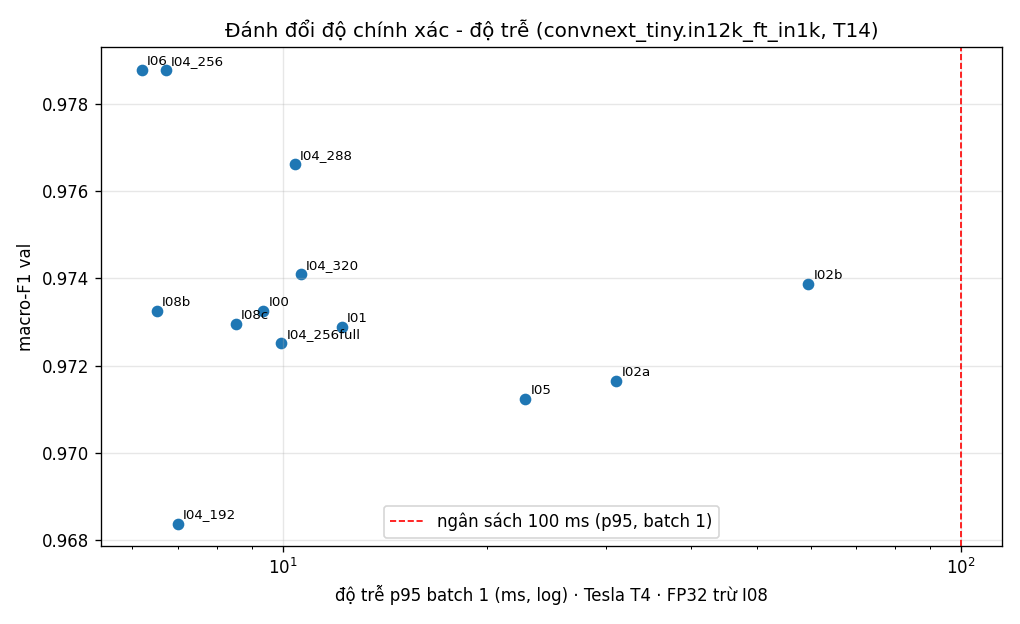

PHƯƠNG PHÁP CHỐT: I04_256


In [10]:
if not os.path.exists("results/inference_val.csv") or "inference" not in json.load(open("results/selection.json")):
    sh(f"{CODE}/step3_inference.py", "--preload", "--workers", WORKERS)
else:
    print("Bước 3 đã xong, bỏ qua (xoá results/inference_val.csv nếu muốn chạy lại)")
display(pd.read_csv("results/inference_val.csv")[["exp_id", "method", "K", "macro_f1", "top1", "ece", "p50_ms",
        "p95_ms", "delta_f1_vs_I00", "cost_vs_I00"]])
display(Image("figures/inference_tradeoff.png", width=750))
print("PHƯƠNG PHÁP CHỐT:", json.load(open("results/selection.json"))["inference"])

## Bước 4 — Chung kết: F01 × 3 seed, **test một lần mỗi seed**, `eval.py score` + `grade`
Cấu hình đã khai báo trong `results/selection.json` trước khi mở test. Script tự bỏ qua seed đã chạy test.

$ /tmp/repo/submissions/2A202602429_vo_minh_quan/code/step4_final.py --preload --workers 4
Chung kết: convnext_tiny + T14 {'epochs': 20} + I04_256 {'views': 'resize', 'space': 'prob', 'res': 256, 'K': 1} + temperature scaling
[F01 seed0] convnext_tiny.in12k_ft_in1k | 27.83M params | 4.470 GMAC | device cuda | amp True | 164 bước/epoch
  ep  1 | train 0.7404 | val loss 0.3435 | val F1 0.8554 | top1 0.8923 | 77s *
  ep  2 | train 0.3335 | val loss 0.1866 | val F1 0.9230 | top1 0.9403 | 50s *
  ep  3 | train 0.2308 | val loss 0.1730 | val F1 0.9332 | top1 0.9460 | 49s *
  ep  4 | train 0.1773 | val loss 0.2130 | val F1 0.9169 | top1 0.9349 | 50s
  ep  5 | train 0.1680 | val loss 0.1433 | val F1 0.9410 | top1 0.9520 | 49s *
  ep  6 | train 0.1374 | val loss 0.1640 | val F1 0.9281 | top1 0.9469 | 49s
  ep  7 | train 0.1212 | val loss 0.1375 | val F1 0.9478 | top1 0.9594 | 49s *
  ep  8 | train 0.1026 | val loss 0.1430 | val F1 0.9424 | top1 0.9563 | 49s
  ep  9 | train 0.0943 | val loss 0.1

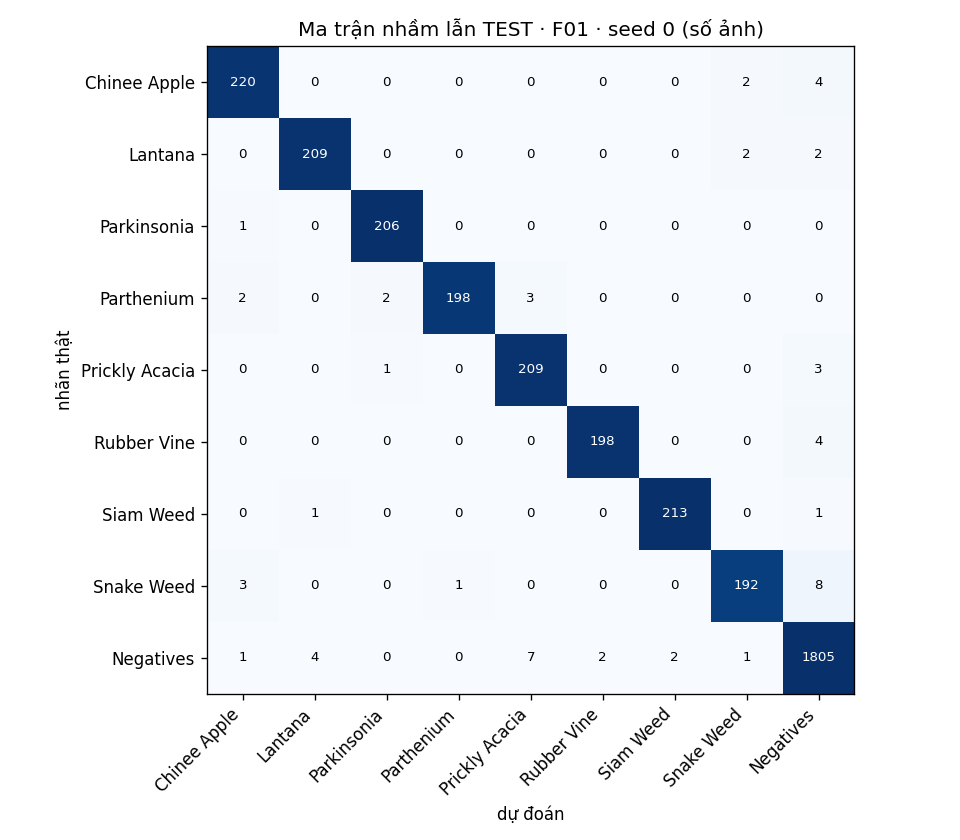

In [11]:
sh(f"{CODE}/step4_final.py", "--preload", "--workers", WORKERS)
print(open("results/grade.txt").read())
display(Image("figures/confusion_F01_seed0.png", width=600))

## Bước 5 — `results.xlsx`, bảng tổng hợp, gói kết quả để tải về

In [12]:
sh(f"{CODE}/make_results.py")
for sheet in ["Summary", "Final"]:
    display(pd.read_excel("results.xlsx", sheet_name=sheet))

# Gói các thư mục cần nộp (KHÔNG gói runs/ vì chứa checkpoint lớn)
import zipfile, glob
zpath = f"{WORK}/submission_outputs.zip"
with zipfile.ZipFile(zpath, "w", zipfile.ZIP_DEFLATED) as z:
    for pattern in ["results.xlsx", "curves/*", "predictions/*", "results/**/*", "figures/*"]:
        for f in glob.glob(pattern, recursive=True):
            if os.path.isfile(f):
                z.write(f)
print("Đã gói:", zpath, f"({os.path.getsize(zpath) / 1e6:.1f} MB)")
if ON_KAGGLE:
    # Output của Kaggle giới hạn dung lượng: bỏ checkpoint (.pt) khỏi Output, chỉ giữ log/json/logit nhỏ
    for f in glob.glob("runs/**/*.pt", recursive=True):
        os.remove(f)
    print("Tải file này ở tab Output của phiên bản Kaggle (lab_day2_work/submission_outputs.zip)")
else:
    print("Tải file này từ Google Drive (MyDrive/lab_day2_work/)")
print("rồi giải nén vào submissions/2A202602429_vo_minh_quan/")

$ /tmp/repo/submissions/2A202602429_vo_minh_quan/code/make_results.py
Đã ghi results.xlsx và results/tables.md
Thiếu ảnh biểu đồ: không


,hạng,exp_id,loại,mô tả,macro-F1 val,top-1 val,độ trễ b1 p95 (ms),chi phí
0,1,I04_256,suy luận,độ phân giải 256 (Resize 293 + CenterCrop),0.978776,0.983719,6.71804,K=1
1,2,I06,suy luận,Greedy soup 3 checkpoint,0.978766,0.983719,6.195429,K=1
2,3,I04_288,suy luận,độ phân giải 288 (Resize 329 + CenterCrop),0.976624,0.981434,10.42764,K=1
3,4,I04_320,suy luận,độ phân giải 320 (Resize 366 + CenterCrop),0.974095,0.97972,10.643699,K=1
4,5,I02b,suy luận,"TTA 10 crop (5 crop + lật), gộp xác suất",0.973863,0.97972,59.541167,K=10
5,6,I03b,suy luận,"TTA 10 crop (5 crop + lật), gộp LOGIT",0.973608,0.97972,NaN,K=10
6,7,I00,suy luận,1 view (center crop 224 từ ảnh 256),0.973249,0.979149,9.363673,K=1
7,8,I08b,suy luận,FP16 (model.half()),0.973249,0.979149,6.51277,K=1
8,9,I07,suy luận,1 view + temperature scaling (T=1.559),0.973249,0.979149,NaN,K=1
9,10,I08c,suy luận,AMP autocast fp16,0.972952,0.978863,8.527859,K=1


,exp_id,cấu hình,seed,macro-F1 val,macro-F1 test,top-1 test,balanced acc test,ECE test,NLL test
0,F01,convnext_tiny + T14 {'epochs': 20} + I04_256 + TS,0,0.977442,0.97901,0.983747,0.97774,0.004171,0.046349
1,F01,convnext_tiny + T14 {'epochs': 20} + I04_256 + TS,1,0.977008,0.982222,0.985458,0.981068,0.00355,0.047106
2,F01,convnext_tiny + T14 {'epochs': 20} + I04_256 + TS,2,0.977692,0.98039,0.984317,0.976321,0.003315,0.054289
3,"F01 (mean ± std, 3 seed)",convnext_tiny + T14 {'epochs': 20} + I04_256 + TS,tổng hợp,0.9774 ± 0.0003,0.9805 ± 0.0016,0.9845 ± 0.0009,0.9784 ± 0.0024,0.0037 ± 0.0004,0.0492 ± 0.0044
4,F01_uncal,"như F01, không temperature scaling",0,NaN,0.97901,0.983747,0.97774,0.009432,0.051334
5,F01_uncal,"như F01, không temperature scaling",1,NaN,0.982222,0.985458,0.981068,0.010171,0.054133
6,F01_uncal,"như F01, không temperature scaling",2,NaN,0.98039,0.984317,0.976321,0.008576,0.063391
7,"F01_uncal (mean ± std, 3 seed)","như F01, không temperature scaling",tổng hợp,NaN,0.9805 ± 0.0016,0.9845 ± 0.0009,0.9784 ± 0.0024,0.0094 ± 0.0008,0.0563 ± 0.0063
8,F01rt,convnext_tiny + T14 + 1 view + TS (thời gian t...,0,NaN,0.968214,0.975192,0.97186,0.004872,0.076525
9,F01rt,convnext_tiny + T14 + 1 view + TS (thời gian t...,1,NaN,0.975392,0.98004,0.980739,0.005011,0.064818


Đã gói: /kaggle/working/lab_day2_work/submission_outputs.zip (20.1 MB)
Tải file này ở tab Output của phiên bản Kaggle (lab_day2_work/submission_outputs.zip)
rồi giải nén vào submissions/2A202602429_vo_minh_quan/
